In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/lakshmi25npathi/imdb-dataset-of-50k-movie-reviews/IMDB Dataset.csv')
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [5]:
df.shape

(50000, 2)

### Data Cleaning (Textual data)

#### 1. Clean
- lower casing
- removing leading and trailing spaces
- removing html tags
- removing urls
- Expanding abbreviations
- spelling correction
- punctuations
- remove special characters

#### 2. Pre-processing
- tokenization
- stop word removal (The, and I, have etc)
- stemming (bringing the word to root form dance, dancing, danced are all conevrted to dance)

#### 3. EDA (Exploratory data anaylysis)

#### 4. Make Features

#### 5. Vectorization (converting the text to numbers)
there are many methods here
- Bag of Words
- TFIDF
- Word2Vec

#### 6. Modelling

#### 7. Evaluation

#### 8. Deploy

#### 9. Monitor

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   review     50000 non-null  object
 1   sentiment  50000 non-null  object
dtypes: object(2)
memory usage: 781.4+ KB


In [7]:
df.duplicated().sum()

np.int64(418)

In [8]:
df = df.drop_duplicates()
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [10]:
# we woudl only take 10k data from the dataset to save the comupation and time

df = df.iloc[:10000]
df.shape

(1000, 2)

### Cleaning

In [11]:
# lowercasing

df['review'] = df['review'].str.lower()

In [12]:
# remove white spaces
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. <br /><br />the...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [13]:
# remove html tags
import re

def remove_html_tags(data):
    data = re.sub('<.*?>', '', data)
    return data

df['review'] = df['review'].apply(remove_html_tags)

In [14]:
# removing urls

# urls can start with any or any formats so using regular expression

def remove_urls(data):
    data = re.sub(r"https?://\S+|www\.\S+", '', data)
    return data

df['review'] = df['review'].apply(remove_urls)
df

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there's a family where a little boy ...,negative
4,"petter mattei's ""love in the time of money"" is...",positive
...,...,...
995,nothing is sacred. just ask ernie fosselius. t...,positive
996,i hated it. i hate self-aware pretentious inan...,negative
997,i usually try to be professional and construct...,negative
998,if you like me is going to see this in a film ...,negative


In [15]:
def remove_abb(data):
    data = re.sub(r"he's", "he is", data)
    data = re.sub(r"there's", "there is", data)
    data = re.sub(r"We're", "We are", data)
    data = re.sub(r"That's", "That is", data)
    data = re.sub(r"won't", "will not", data)
    data = re.sub(r"they're", "they are", data)
    data = re.sub(r"Can't", "Cannot", data)
    data = re.sub(r"wasn't", "was not", data)
    data = re.sub(r"don\x89Ûªt", "do not", data)
    data= re.sub(r"aren't", "are not", data)
    data = re.sub(r"isn't", "is not", data)
    data = re.sub(r"What's", "What is", data)
    data = re.sub(r"haven't", "have not", data)
    data = re.sub(r"hasn't", "has not", data)
    data = re.sub(r"There's", "There is", data)
    data = re.sub(r"He's", "He is", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"You're", "You are", data)
    data = re.sub(r"I'M", "I am", data)
    data = re.sub(r"shouldn't", "should not", data)
    data = re.sub(r"wouldn't", "would not", data)
    data = re.sub(r"i'm", "I am", data)
    data = re.sub(r"I\x89Ûªm", "I am", data)
    data = re.sub(r"I'm", "I am", data)
    data = re.sub(r"Isn't", "is not", data)
    data = re.sub(r"Here's", "Here is", data)
    data = re.sub(r"you've", "you have", data)
    data = re.sub(r"you\x89Ûªve", "you have", data)
    data = re.sub(r"we're", "we are", data)
    data = re.sub(r"what's", "what is", data)
    data = re.sub(r"couldn't", "could not", data)
    data = re.sub(r"we've", "we have", data)
    data = re.sub(r"it\x89Ûªs", "it is", data)
    data = re.sub(r"doesn\x89Ûªt", "does not", data)
    data = re.sub(r"It\x89Ûªs", "It is", data)
    data = re.sub(r"Here\x89Ûªs", "Here is", data)
    data = re.sub(r"who's", "who is", data)
    data = re.sub(r"I\x89Ûªve", "I have", data)
    data = re.sub(r"y'all", "you all", data)
    data = re.sub(r"can\x89Ûªt", "cannot", data)
    data = re.sub(r"would've", "would have", data)
    data = re.sub(r"it'll", "it will", data)
    data = re.sub(r"we'll", "we will", data)
    data = re.sub(r"wouldn\x89Ûªt", "would not", data)
    data = re.sub(r"We've", "We have", data)
    data = re.sub(r"he'll", "he will", data)
    data = re.sub(r"Y'all", "You all", data)
    data = re.sub(r"Weren't", "Were not", data)
    data = re.sub(r"Didn't", "Did not", data)
    data = re.sub(r"they'll", "they will", data)
    data = re.sub(r"they'd", "they would", data)
    data = re.sub(r"DON'T", "DO NOT", data)
    data = re.sub(r"That\x89Ûªs", "That is", data)
    data = re.sub(r"they've", "they have", data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"should've", "should have", data)
    data = re.sub(r"You\x89Ûªre", "You are", data)
    data = re.sub(r"where's", "where is", data)
    data = re.sub(r"Don\x89Ûªt", "Do not", data)
    data = re.sub(r"we'd", "we would", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"weren't", "were not", data)
    data = re.sub(r"They're", "They are", data)
    data = re.sub(r"Can\x89Ûªt", "Cannot", data)
    data = re.sub(r"you\x89Ûªll", "you will", data)
    data = re.sub(r"I\x89Ûªd", "I would", data)
    data = re.sub(r"let's", "let us", data)
    data = re.sub(r"it's", "it is", data)
    data = re.sub(r"can't", "cannot", data)
    data = re.sub(r"don't", "do not", data)
    data = re.sub(r"you're", "you are", data)
    data = re.sub(r"i've", "I have", data)
    data = re.sub(r"that's", "that is", data)
    data = re.sub(r"i'll", "I will", data)
    data = re.sub(r"doesn't", "does not",data)
    data = re.sub(r"i'd", "I would", data)
    data = re.sub(r"didn't", "did not", data)
    data = re.sub(r"ain't", "am not", data)
    data = re.sub(r"you'll", "you will", data)
    data = re.sub(r"I've", "I have", data)
    data = re.sub(r"Don't", "do not", data)
    data = re.sub(r"I'll", "I will", data)
    data = re.sub(r"I'd", "I would", data)
    data = re.sub(r"Let's", "Let us", data)
    data = re.sub(r"you'd", "You would", data)
    data = re.sub(r"It's", "It is", data)
    data = re.sub(r"Ain't", "am not", data)
    data = re.sub(r"Haven't", "Have not", data)
    data = re.sub(r"Could've", "Could have", data)
    data = re.sub(r"youve", "you have", data)  
    data = re.sub(r"donå«t", "do not", data)
    
    return data

In [16]:
df['review'] = df['review'].apply(remove_abb)
df.head()

,review,sentiment
0,one of the other reviewers has mentioned that ...,positive
1,a wonderful little production. the filming tec...,positive
2,i thought this was a wonderful way to spend ti...,positive
3,basically there is a family where a little boy...,negative
4,"petter mattei's ""love in the time of money"" is...",positive


In [17]:
from textblob import TextBlob

def correct_spelling(text):
    return TextBlob(text).correct().string

In [18]:
ts = 'Tihs is my worng sentnece.'

correct_spelling(ts)

'His is my wrong sentence.'

In [ ]:
df['review'] = df['review'].apply(correct_spelling)

In [20]:
import string

def remove_punctuation(text):
    for i in string.punctuation:
        if i in text:
            text = text.replace(i, '')
    return text

In [21]:
df['review'] = df['review'].apply(remove_punctuation)

### Preprocessing


In [22]:
from nltk import word_tokenize

In [24]:
df['tokenized_review'] = df['review'].apply(word_tokenize)
df.head()

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, of, the, other, reviewers, has, mentione..."
1,a wonderful little production the filming tech...,positive,"[a, wonderful, little, production, the, filmin..."
2,i thought this was a wonderful way to spend ti...,positive,"[i, thought, this, was, a, wonderful, way, to,..."
3,basically there is a family where a little boy...,negative,"[basically, there, is, a, family, where, a, li..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, in, the, time, of, mon..."


In [25]:
# stop word removal

from nltk.corpus import stopwords

In [27]:
def remove_stopwords(text):
    L = []
    for word in text:
        if word not in stopwords.words('english'):
            L.append(word)

    return L

In [28]:
df['tokenized_review'] = df['tokenized_review'].apply(remove_stopwords)

In [29]:
df.head()

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,..."


### EDA and Feature Engineering

- Distribution of text length/word count
- common unigrams/bigrams/trigrams
- Worldcloud

In [30]:
df.head()

,review,sentiment,tokenized_review
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e..."
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn..."
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su..."
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,..."
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,..."


In [31]:
df['char_length'] = df['review'].str.len()
df.head()

,review,sentiment,tokenized_review,char_length
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1674
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn...",936
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",882
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,...",694
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,...",1237


In [32]:
df['word_length'] = df['tokenized_review'].apply(len)
df.head()

,review,sentiment,tokenized_review,char_length,word_length
0,one of the other reviewers has mentioned that ...,positive,"[one, reviewers, mentioned, watching, 1, oz, e...",1674,166
1,a wonderful little production the filming tech...,positive,"[wonderful, little, production, filming, techn...",936,84
2,i thought this was a wonderful way to spend ti...,positive,"[thought, wonderful, way, spend, time, hot, su...",882,87
3,basically there is a family where a little boy...,negative,"[basically, family, little, boy, jake, thinks,...",694,64
4,petter matteis love in the time of money is a ...,positive,"[petter, matteis, love, time, money, visually,...",1237,125


In [33]:
import seaborn as sns

/tmp/ipykernel_58/4093798214.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['char_length'])


<Axes: xlabel='char_length', ylabel='Density'>

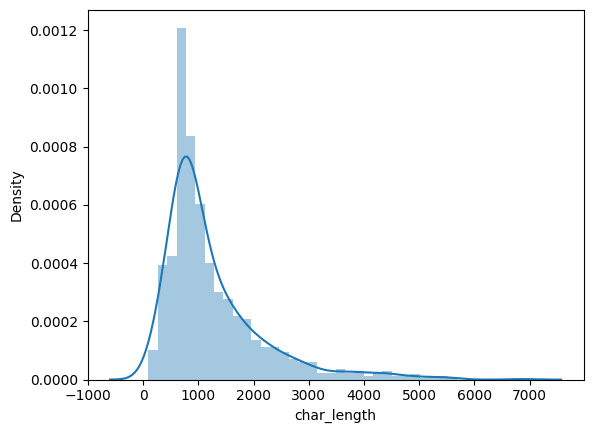

In [34]:
sns.distplot(df['char_length'])

/tmp/ipykernel_58/2354756712.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['word_length'])


<Axes: xlabel='word_length', ylabel='Density'>

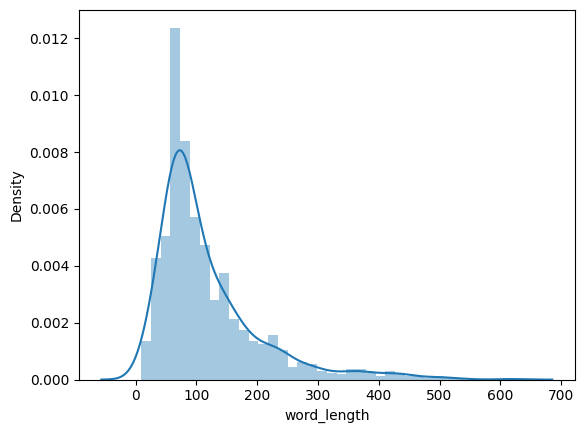

In [35]:
sns.distplot(df['word_length'])

In [37]:
df[df['sentiment'] == 'positive']['char_length']

0      1674
1       936
2       882
4      1237
5       637
       ... 
987     547
988     945
992     372
994    1009
995    1141
Name: char_length, Length: 501, dtype: int64

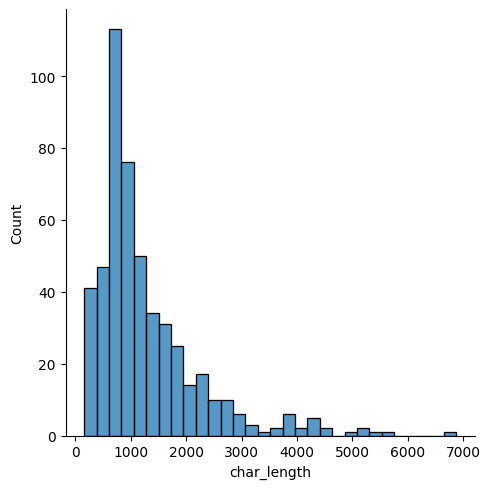

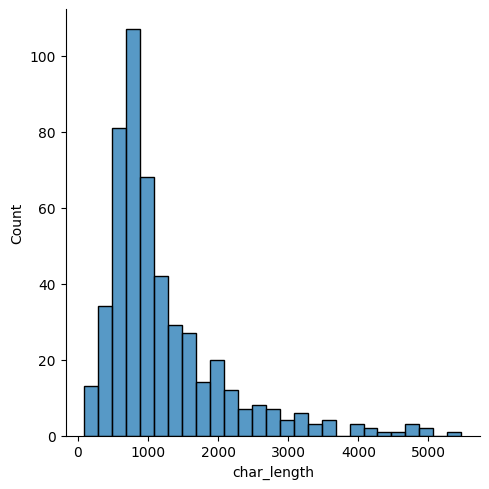

In [38]:
sns.displot(df[df['sentiment'] == 'positive']['char_length'])
sns.displot(df[df['sentiment'] == 'negative']['char_length'])

#### unigram/bigram/trigram

example: I am sham my first kaggle notebook

##### unigram: [I] [am] [sham] [my] [first] [kaggle] [notebook]

##### bigram: [I am] [sham my] [first kaggle] [notebook]

##### trigram: [I am sham] [my first kaggle] [notebook]


In [39]:
from nltk import ngrams

In [40]:
pd.Series(ngrams(df['tokenized_review'].sum(), 2)).value_counts()

(ever, seen)          51
(special, effects)    49
(I, would)            46
(I, seen)             41
(even, though)        40
                      ..
(animal, noises)       1
(age, animal)          1
(half, age)            1
(oz, brutality)        1
(struck, oz)           1
Name: count, Length: 104016, dtype: int64

In [41]:
pd.Series(ngrams(df['tokenized_review'].sum(), 3)).value_counts()

(I, ever, seen)               21
(worst, movie, ever)          13
(You, would, think)            9
(I, would, like)               8
(movie, ever, seen)            8
                              ..
(stage, needed, female)        1
(flynn, stage, needed)         1
(match, flynn, stage)          1
(good, match, flynn)           1
(charges, time, admirably)     1
Name: count, Length: 117458, dtype: int64

In [43]:
### positive review bigram and trigram

pd.Series(ngrams(df[df['sentiment'] == 'positive']['tokenized_review'].sum(), 2)).value_counts()

(one, best)                  33
(would, like)                26
(I, would)                   22
(special, effects)           21
(watch, movie)               20
                             ..
(realize, dreammeanwhile)     1
(dreammeanwhile, julias)      1
(brotherinlaw, murdered)      1
(murdered, nearest)           1
(money, go)                   1
Name: count, Length: 55620, dtype: int64

In [44]:
pd.Series(ngrams(df[df['sentiment'] == 'negative']['tokenized_review'].sum(), 2)).value_counts()

(ever, seen)                40
(special, effects)          28
(waste, time)               27
(see, movie)                26
(I, seen)                   24
                            ..
(feeling, played)            1
(played, slasherhorror)      1
(slasherhorror, element)     1
(element, introduced)        1
(friend, bus)                1
Name: count, Length: 51780, dtype: int64

In [45]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

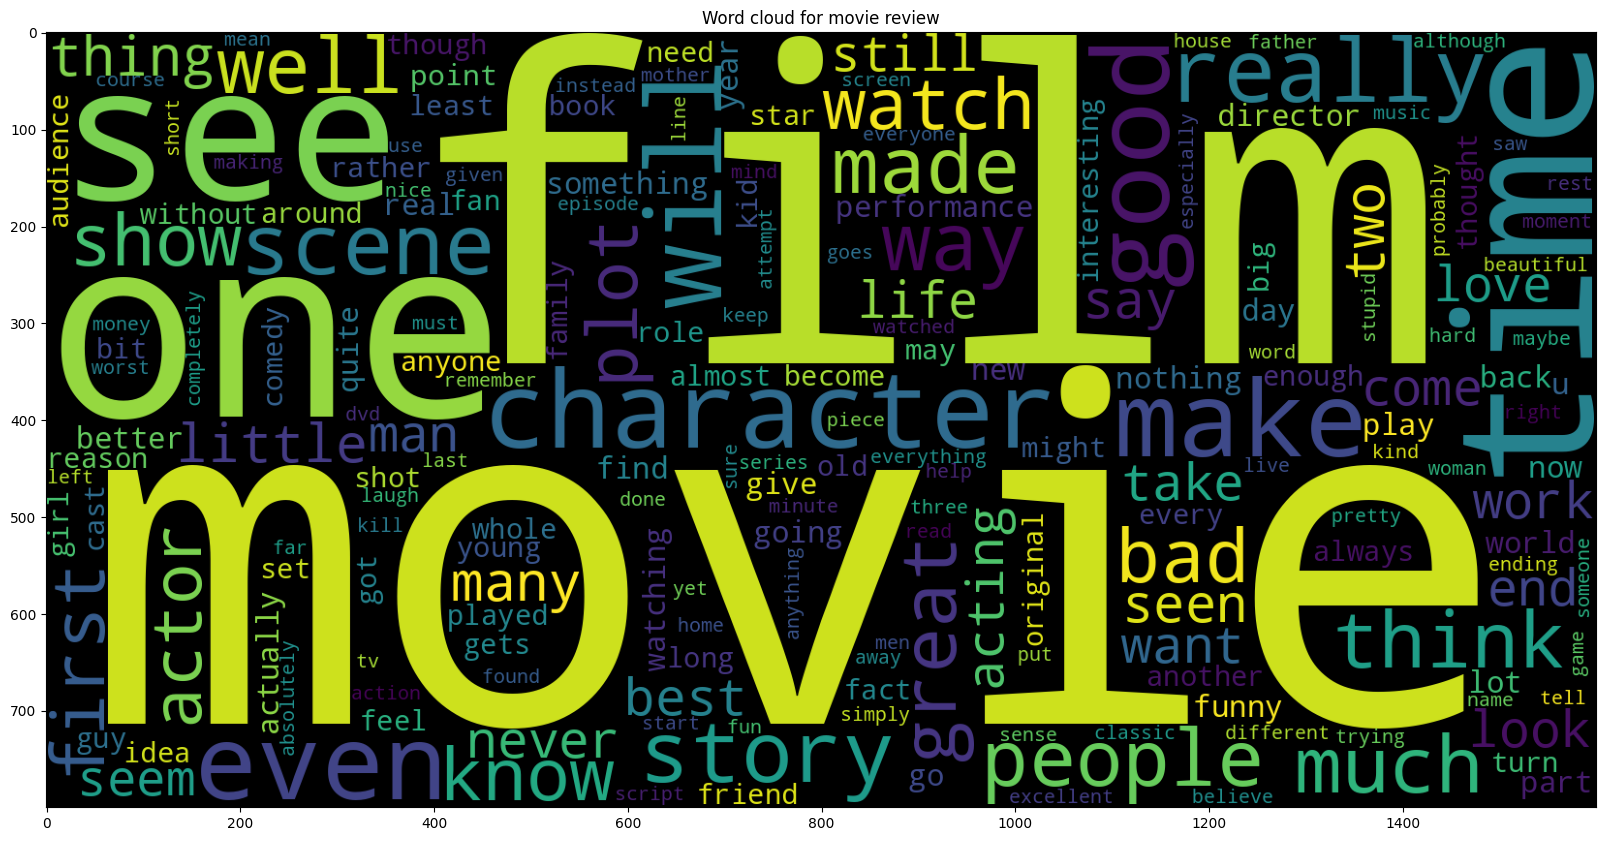

In [50]:
plt.figure(figsize=(20, 20))
wc = WordCloud(width=1600, height=800).generate(" ".join(df['review']))
plt.title('Word cloud for movie review')
plt.imshow(wc);

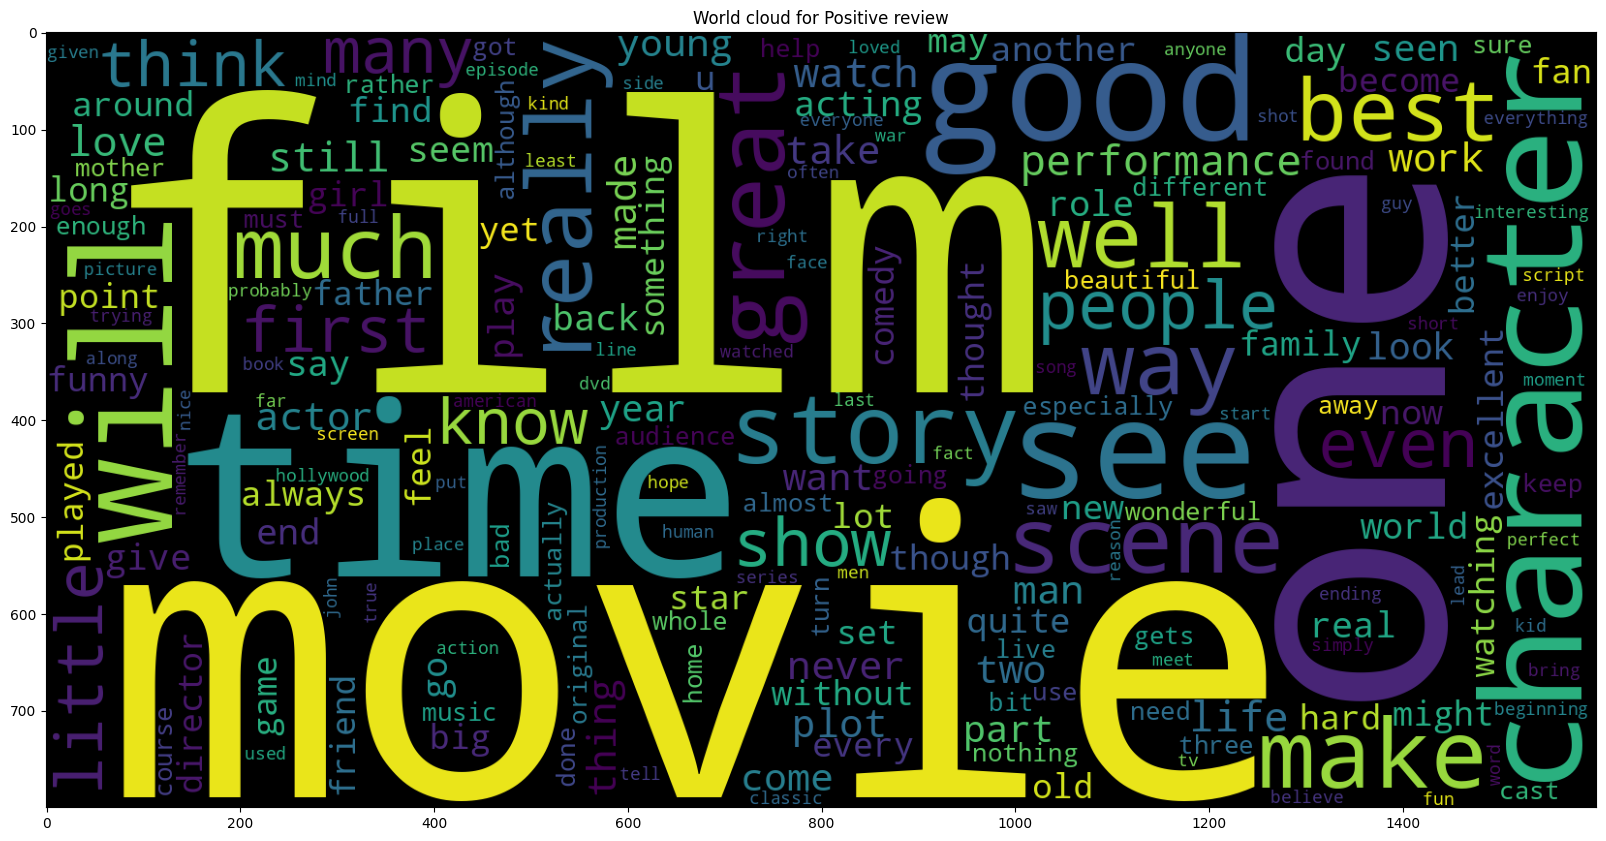

In [51]:
plt.figure(figsize=(20, 20))
wc = WordCloud(width=1600, height=800).generate(" ".join(df[df['sentiment'] == 'positive']['review']))
plt.title('World cloud for Positive review')
plt.imshow(wc)

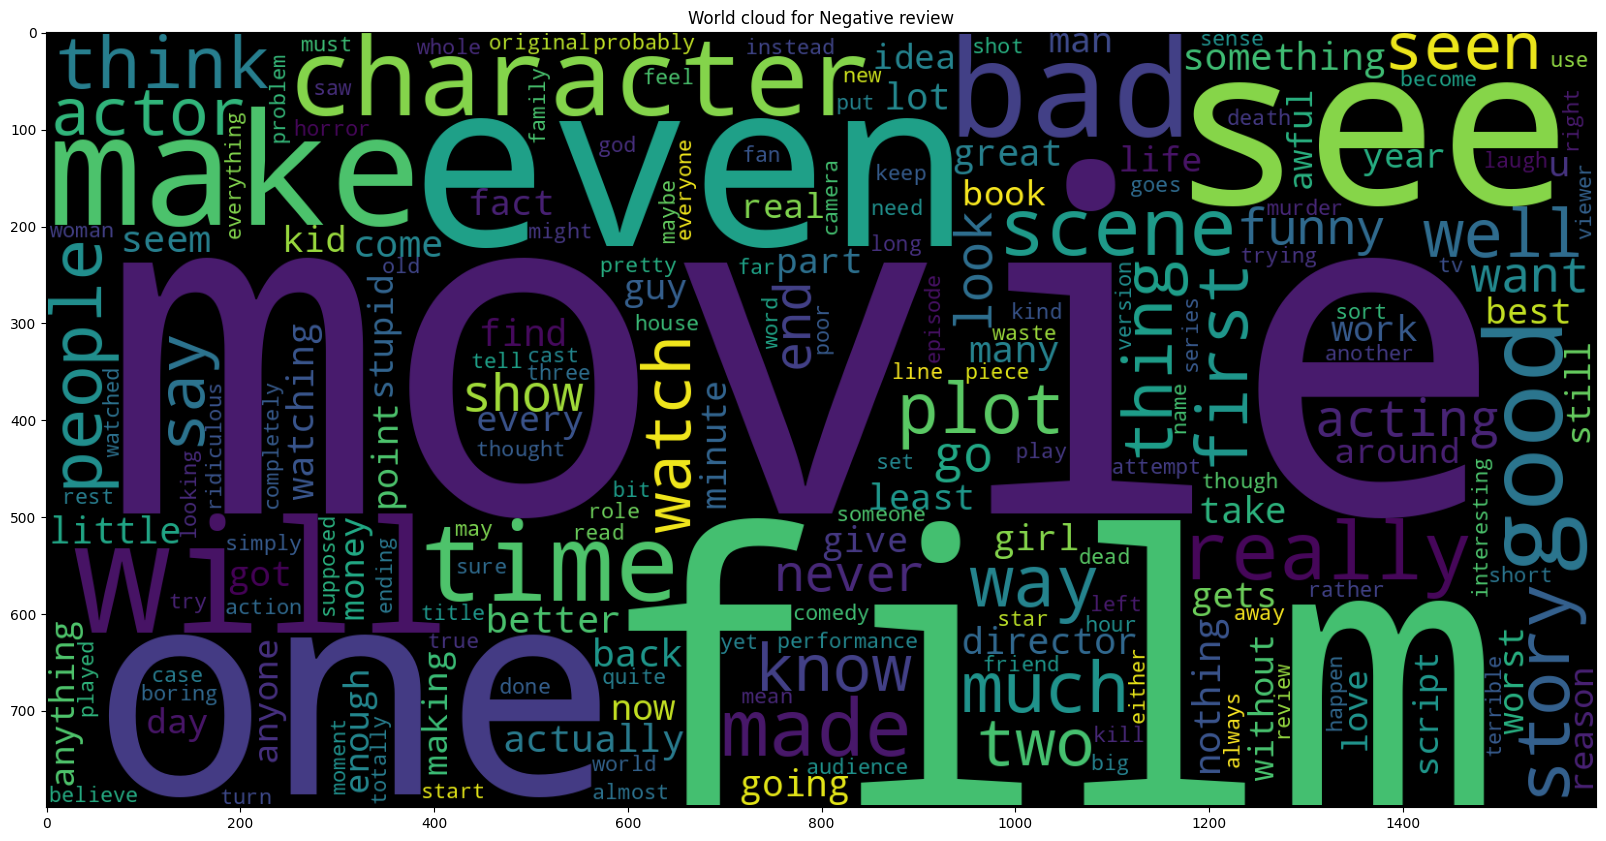

In [52]:
plt.figure(figsize=(20, 20))
wc = WordCloud(width=1600, height=800).generate(" ".join(df[df['sentiment'] == 'negative']['review']))
plt.title('World cloud for Negative review')
plt.imshow(wc)

In [55]:
from sklearn.feature_extraction.text import CountVectorizer
count_vectorizer = CountVectorizer(max_features=5000)
bag_of_words = count_vectorizer.fit_transform(df['review'])
bag_of_words = pd.DataFrame(bag_of_words.toarray(), columns=count_vectorizer.get_feature_names_out())

In [56]:
bag_of_words

,10,100,1000,1010,11,110,12,13,13th,14,...,youtube,zany,zero,zip,zodiac,zombie,zombies,zone,zooms,zp
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
996,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
997,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,1,1,0,0,0
998,1,0,0,0,0,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [57]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_result = pca.fit_transform(bag_of_words.values)

In [58]:
pca_result.shape

(1000, 2)

<Axes: >

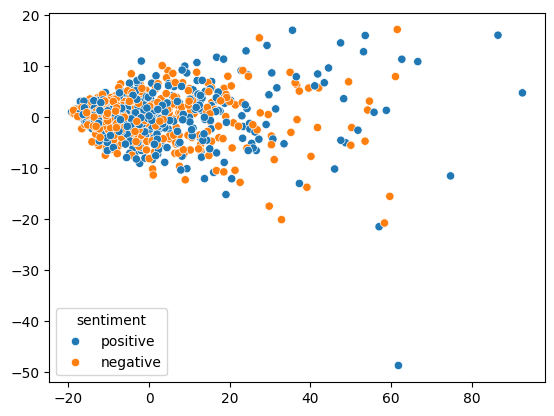

In [61]:
sns.scatterplot(x=pca_result[:, 0], y=pca_result[:, 1], hue=df['sentiment'])